# Synthetic NCS oil pipeline and terminal optimization

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/equinor/neqsim/blob/master/examples/notebooks/process/norwegian_ncs_oil_network_optimization.ipynb)

This executed companion to the gas example demonstrates issues #2665, #2666, #2668,
and #2669:

1. a first-class liquid pump edge;
2. crude assays on a declared common component slate;
3. perfect-mixed and segregated terminal tanks;
4. parcel identity, receipts, cargo windows, berths, and availability;
5. EOS-calculated nonlinear oil properties plus governed assay attributes;
6. deterministic mass/component-conservative scheduling.

All compositions, quantities, limits, and operating cases are synthetic.
Public NCS facility and crude names provide context only; the values are not
operator acceptance specifications.

## Setup

In [1]:
import subprocess
import sys

try:
    from neqsim import jneqsim, jpype
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "neqsim"])
    from neqsim import jneqsim, jpype

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("NeqSim JVM and Python bridge loaded")

NeqSim JVM and Python bridge loaded


In [2]:
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
LoopedPipeNetwork = jneqsim.process.equipment.network.LoopedPipeNetwork
CrudeAssay = jneqsim.process.equipment.network.CrudeAssay
CrudeParcel = jneqsim.process.equipment.network.CrudeParcel
OilTerminalTank = jneqsim.process.equipment.network.OilTerminalTank
OilTerminalNode = jneqsim.process.equipment.network.OilTerminalNode
OilNetworkSchedule = jneqsim.process.equipment.network.OilNetworkSchedule
OilNetworkScheduleResult = jneqsim.process.equipment.network.OilNetworkScheduleResult
CargoNomination = jneqsim.process.equipment.network.CargoNomination
NetworkQualityProfile = jneqsim.process.equipment.network.NetworkQualityProfile
OilQualityMetric = jneqsim.process.equipment.network.OilQualityMetric
QualityReference = jneqsim.process.equipment.network.QualityReference
Arrays = jpype.JClass("java.util.Arrays")

print("Pump, assay, terminal, quality, and scheduling classes loaded")

Pump, assay, terminal, quality, and scheduling classes loaded


## Synthetic assays on one declared slate

The example uses two named components to keep the public demonstration compact.
Real assays may use a governed TBP/plus-fraction slate. NeqSim rejects unlike
definitions instead of mixing by array position. Sulfur is mass-weighted;
water/BS&W is volume-weighted using EOS density.

In [3]:
def make_assay(name, n_c10, n_c16, sulfur, water):
    fluid = SystemSrkEos(288.15, 5.0)
    fluid.addComponent("nC10", n_c10)
    fluid.addComponent("nC16", n_c16)
    fluid.setMixingRule("classic")
    assay = CrudeAssay(
        name,
        "Synthetic common C10-C16 slate",
        fluid,
        "Synthetic representative public-data example",
        "2026-01-01",
    )
    assay.addMeasuredAttribute(
        "sulfurMassPercent", sulfur, "mass%",
        "Synthetic assay", "mass-weighted",
    )
    assay.addMeasuredAttribute(
        "waterBswVolumePercent", water, "vol%",
        "Synthetic assay", "volume-weighted",
    )
    return assay


oseberg = make_assay("Oseberg-like", 0.70, 0.30, 0.30, 0.10)
grane = make_assay("Grane-like", 0.30, 0.70, 0.90, 0.20)
troll = make_assay("Troll-like", 0.55, 0.45, 0.45, 0.15)

assay_table = pd.DataFrame([
    {"feed": "Oseberg-like", "nC10_mol_fraction": 0.70,
     "sulfur_mass_pct": 0.30, "water_BSW_vol_pct": 0.10},
    {"feed": "Grane-like", "nC10_mol_fraction": 0.30,
     "sulfur_mass_pct": 0.90, "water_BSW_vol_pct": 0.20},
    {"feed": "Troll-like", "nC10_mol_fraction": 0.55,
     "sulfur_mass_pct": 0.45, "water_BSW_vol_pct": 0.15},
])
assay_table

,feed,nC10_mol_fraction,sulfur_mass_pct,water_BSW_vol_pct
0,Oseberg-like,0.70,0.30,0.10
1,Grane-like,0.30,0.90,0.20
2,Troll-like,0.55,0.45,0.15


## Oil export booster

The network pump uses a fixed 10 bara outlet, 75% efficiency, a rated-power
limit, and a minimum-flow constraint. A curve-backed pump can be substituted
with `addPumpWithCurve`.

In [4]:
pump_network = LoopedPipeNetwork("Synthetic oil export booster")
pump_network.setFluidTemplate(oseberg.getFluid())
pump_network.setSolverType(LoopedPipeNetwork.SolverType.NEWTON_RAPHSON)
pump_network.setMaxIterations(100)
pump_network.setTolerance(500.0)
pump_network.setCompositionalHydraulicsEnabled(True)
pump_network.setThermalHydraulicsEnabled(True)
pump_network.setCouplingMaxIterations(5)
pump_network.setCouplingTolerances(1.0e-3, 100.0)
pump_network.addSourceNode("suction", 5.0, 0.0)
pump_network.addFixedPressureSinkNode("terminal receipt", 10.0)
pump = pump_network.addPump(
    "suction", "terminal receipt", "export booster", 10.0, 0.75
)
pump.setPumpRatedPowerKW(10000.0)
pump.setPumpMinimumFlowKgS(0.01)
pump_network.setNodeFluid("suction", oseberg.getFluid())
pump_network.run()

pump_table = pd.Series({
    "network_converged": bool(pump_network.isConverged()),
    "flow_kg_s": float(pump.getFlowRate()),
    "head_m": float(pump.getPumpHeadM()),
    "shaft_power_kW": float(pump.getPumpPowerKW()),
    "efficiency": float(pump.getPumpEfficiency()),
    "power_residual_kW": float(pump.getPumpPowerResidualKW()),
    "minimum_flow_residual_kg_s": float(
        pump.getPumpMinimumFlowResidualKgS()
    ),
    "operating_status": str(pump.getPumpOperatingStatus()),
})
pump_table.to_frame("value")

,value
network_converged,True
flow_kg_s,110.620315
head_m,65.159362
shaft_power_kW,124.202149
efficiency,0.75
power_residual_kW,0.0
minimum_flow_residual_kg_s,0.0
operating_status,NORMAL


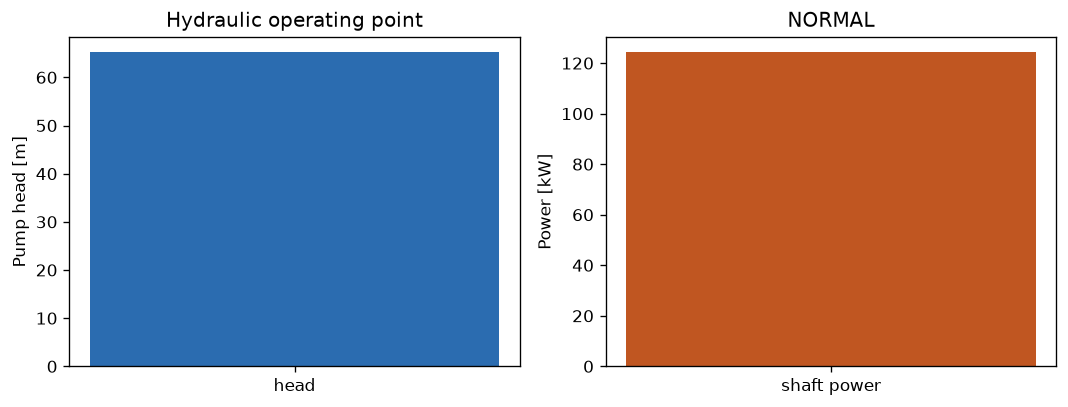

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].bar(["head"], [float(pump.getPumpHeadM())], color="#2b6cb0")
axes[0].set_ylabel("Pump head [m]")
axes[0].set_title("Hydraulic operating point")
axes[1].bar(["shaft power"], [float(pump.getPumpPowerKW())], color="#c05621")
axes[1].set_ylabel("Power [kW]")
axes[1].set_title(str(pump.getPumpOperatingStatus()))
fig.tight_layout()
plt.show()

## Terminal, tanks, and cargo quality

Cavern A is explicitly perfect-mixed. Cavern B and Tank C retain segregated
FIFO parcels. The quality profile combines EOS-calculated API/density,
viscosity, and vapor pressure with assay-backed sulfur and water/BS&W.

In [6]:
terminal = OilTerminalNode("Synthetic Sture-like terminal")

mixed = OilTerminalTank(
    "Cavern A", 500000.0, 20000.0, 100.0, 100.0,
    OilTerminalTank.MixingMode.PERFECT_MIXED,
)
mixed.addOpeningInventory(CrudeParcel(
    "opening-A", 150000.0, oseberg, -1, "opening", "Synthetic",
))

segregated = OilTerminalTank(
    "Cavern B", 400000.0, 10000.0, 100.0, 100.0,
    OilTerminalTank.MixingMode.SEGREGATED,
)
segregated.addOpeningInventory(CrudeParcel(
    "opening-B", 120000.0, grane, -1, "opening", "Synthetic",
))

spare = OilTerminalTank(
    "Tank C", 300000.0, 5000.0, 100.0, 100.0,
    OilTerminalTank.MixingMode.SEGREGATED,
)
spare.addOpeningInventory(CrudeParcel(
    "opening-C", 50000.0, troll, -1, "opening", "Synthetic",
))

terminal.addTank(mixed)
terminal.addTank(segregated)
terminal.addTank(spare)

profile = NetworkQualityProfile("Synthetic educational cargo limits")
profile.withEffectivePeriod("education-v1", "2026-01-01", None)
profile.withProvenance(
    "Synthetic limits; not operator acceptance criteria"
)
profile.addRange(
    OilQualityMetric.API_GRAVITY, 5.0, 80.0, "degAPI",
    QualityReference.atTemperature(15.0, "C"),
)
profile.addRange(
    OilQualityMetric.DENSITY, 500.0, 1100.0, "kg/m3",
    QualityReference.atTemperature(15.0, "C"),
)
profile.addUpperLimit(
    OilQualityMetric.DYNAMIC_VISCOSITY, 1000.0, "mPa.s",
    QualityReference.atTemperature(20.0, "C"),
)
profile.addUpperLimit(
    OilQualityMetric.TRUE_VAPOR_PRESSURE, 20.0, "bara",
    QualityReference.atTemperature(37.8, "C"),
)
profile.addMeasuredAttributeLimit(
    "oil", "sulfurMassPercent", None, 2.0, "mass%",
    "Synthetic assay",
)
profile.addMeasuredAttributeLimit(
    "oil", "waterBswVolumePercent", None, 0.5, "vol%",
    "Synthetic assay",
)

print("Terminal and synthetic cargo quality profile created")

Terminal and synthetic cargo quality profile created


## Three periods, three feeds, two cargo windows

Tank C is unavailable for the first two periods. The cargoes use different
berths and preferred tanks. The pump network is attached as a period hydraulic
feasibility check.

In [7]:
schedule_model = OilNetworkSchedule(terminal)
schedule_model.addHourlyPeriods("2026-01-01T00:00:00Z", 3)
schedule_model.addReceipt("Cavern A", CrudeParcel(
    "Oseberg receipt", 40000.0, oseberg, 0,
    "Oseberg Transport System-like route", "Synthetic public context",
))
schedule_model.addReceipt("Cavern A", CrudeParcel(
    "Troll receipt", 30000.0, troll, 1,
    "Troll-like route", "Synthetic public context",
))
schedule_model.addReceipt("Cavern B", CrudeParcel(
    "Grane receipt", 25000.0, grane, 0,
    "Grane Oil Pipeline-like route", "Synthetic public context",
))
schedule_model.addCargoNomination(CargoNomination(
    "cargo-1", 50000.0, 0, 1, "berth-1", 50.0,
    profile, Arrays.asList(["Cavern A"]),
))
schedule_model.addCargoNomination(CargoNomination(
    "cargo-2", 20000.0, 1, 2, "berth-2", 50.0,
    profile, Arrays.asList(["Cavern B"]),
))
schedule_model.setTankAvailability("Tank C", 0, 2, False)
schedule_model.setHydraulicNetwork(pump_network)

schedule = schedule_model.optimize()
repeat = schedule_model.optimize()

schedule_summary = pd.Series({
    "feasible": bool(schedule.isFeasible()),
    "cargoes_loaded": int(schedule.getCargoes().size()),
    "mass_balance_residual_kg": float(
        schedule.getMassBalanceResidualKg()
    ),
    "max_component_residual_kg": float(
        schedule.getMaxComponentBalanceResidualKg()
    ),
    "active_constraints": int(schedule.getActiveConstraints().size()),
    "deterministic_repeat": (
        float(schedule.getTerminalInventories().get("Cavern A").getMassKg())
        == float(repeat.getTerminalInventories().get("Cavern A").getMassKg())
    ),
})
schedule_summary.to_frame("value")

,value
feasible,True
cargoes_loaded,2
mass_balance_residual_kg,0.0
max_component_residual_kg,0.0
active_constraints,0
deterministic_repeat,True


In [8]:
tank_names = ["Cavern A", "Cavern B", "Tank C"]
inventory_rows = []
for tank_name in tank_names:
    inventory_rows.append({
        "boundary": "opening",
        "tank": tank_name,
        "mass_kg": {
            "Cavern A": 150000.0,
            "Cavern B": 120000.0,
            "Tank C": 50000.0,
        }[tank_name],
    })
for period_result in schedule.getPeriods():
    boundary = f'period {int(period_result.getPeriod().getIndex()) + 1}'
    for tank_name in tank_names:
        inventory_rows.append({
            "boundary": boundary,
            "tank": tank_name,
            "mass_kg": float(
                period_result.getClosingInventories()
                .get(tank_name).getMassKg()
            ),
        })
inventory_table = pd.DataFrame(inventory_rows)
inventory_pivot = inventory_table.pivot(
    index="boundary", columns="tank", values="mass_kg"
).reindex(["opening", "period 1", "period 2", "period 3"])
inventory_pivot

tank,Cavern A,Cavern B,Tank C
boundary,,,
opening,150000.0,120000.0,50000.0
period 1,140000.0,145000.0,50000.0
period 2,170000.0,125000.0,50000.0
period 3,170000.0,125000.0,50000.0


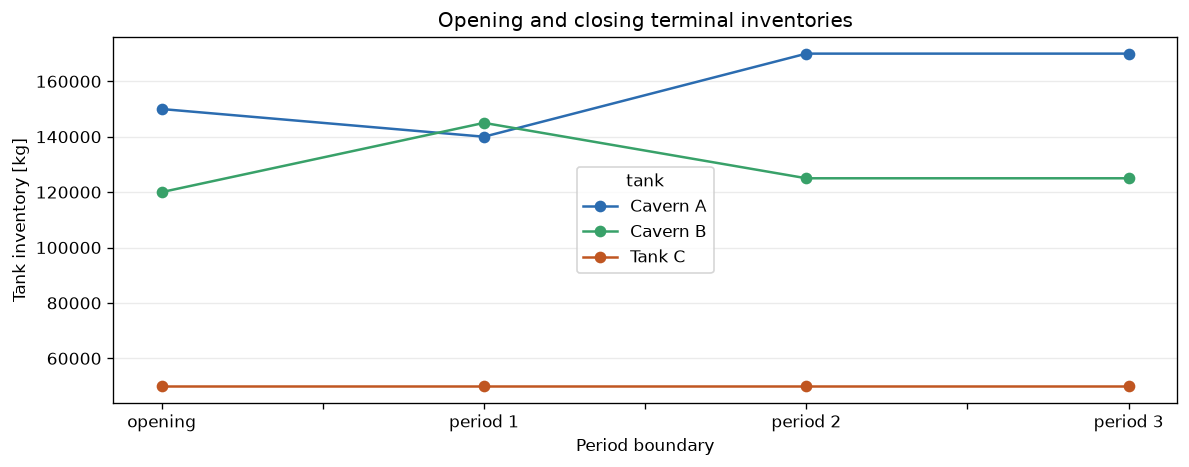

In [9]:
ax = inventory_pivot.plot(
    marker="o", figsize=(10, 4), color=["#2b6cb0", "#38a169", "#c05621"]
)
ax.set_ylabel("Tank inventory [kg]")
ax.set_xlabel("Period boundary")
ax.set_title("Opening and closing terminal inventories")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## Cargo quality and parcel identity

The perfect-mixed cargo has a thermodynamic blend assay. The segregated cargo
retains the Grane-like opening parcel assay and never crosses a parcel boundary.

In [10]:
quality_rows = []
for cargo_id in ["cargo-1", "cargo-2"]:
    cargo = schedule.getCargoes().get(cargo_id)
    for item in cargo.getQualityReport().getResults():
        quality_rows.append({
            "cargo": cargo_id,
            "source_tank": str(cargo.getTankName()),
            "metric": str(item.getAttributeName()) if item.getAttributeName()
                      is not None else str(item.getMetricKey()),
            "value": None if item.getValue() is None else float(item.getValue()),
            "unit": str(item.getUnit()),
            "margin": None if item.getMargin() is None else float(item.getMargin()),
            "status": str(item.getStatus()),
            "method": str(item.getMethod()),
        })
quality_table = pd.DataFrame(quality_rows)
quality_table

,cargo,source_tank,metric,value,unit,margin,status,method
0,cargo-1,Cavern A,apiGravity,49.263014,degAPI,30.736986,PASS,API gravity from EOS density
1,cargo-1,Cavern A,density,782.022610,kg/m3,282.022610,PASS,EOS density at reference temperature
2,cargo-1,Cavern A,dynamicViscosity,2.287456,mPa.s,997.712544,PASS,EOS physical-property model
3,cargo-1,Cavern A,trueVaporPressure,0.002842,bara,19.997158,PASS,True vapor pressure (Standard_TVP)
4,cargo-1,Cavern A,sulfurMassPercent,0.300000,mass%,1.700000,PASS,Synthetic assay
5,cargo-1,Cavern A,waterBswVolumePercent,0.100000,vol%,0.400000,PASS,Synthetic assay
6,cargo-2,Cavern B,apiGravity,42.590981,degAPI,37.409019,PASS,API gravity from EOS density
7,cargo-2,Cavern B,density,811.993607,kg/m3,288.006393,PASS,EOS density at reference temperature
8,cargo-2,Cavern B,dynamicViscosity,5.037682,mPa.s,994.962318,PASS,EOS physical-property model
9,cargo-2,Cavern B,trueVaporPressure,0.001232,bara,19.998768,PASS,True vapor pressure (Standard_TVP)


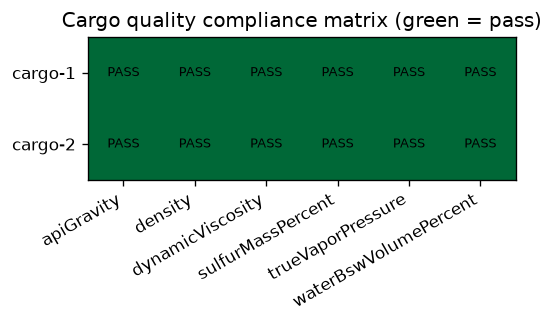

In [11]:
status_pivot = (
    quality_table.assign(
        pass_value=lambda frame: (frame["status"] == "PASS").astype(int)
    )
    .pivot(index="cargo", columns="metric", values="pass_value")
)

fig, ax = plt.subplots(figsize=(11, 2.8))
image = ax.imshow(status_pivot.values, cmap="RdYlGn", vmin=0, vmax=1)
ax.set_xticks(np.arange(status_pivot.shape[1]), status_pivot.columns, rotation=30, ha="right")
ax.set_yticks(np.arange(status_pivot.shape[0]), status_pivot.index)
ax.set_title("Cargo quality compliance matrix (green = pass)")
for row in range(status_pivot.shape[0]):
    for col in range(status_pivot.shape[1]):
        ax.text(col, row, "PASS" if status_pivot.iloc[row, col] else "FAIL",
                ha="center", va="center", fontsize=8)
fig.tight_layout()
plt.show()

## Validation gates and JSON round trip

In [12]:
restored = OilNetworkScheduleResult.fromJson(schedule.toJson())

assert pump_network.isConverged()
assert 0.0 < float(pump.getPumpHeadM()) < 500.0
assert float(pump.getPumpPowerResidualKW()) == 0.0
assert schedule.isFeasible()
assert abs(float(schedule.getMassBalanceResidualKg())) < 1.0e-6
assert float(schedule.getMaxComponentBalanceResidualKg()) < 1.0e-6
assert int(schedule.getCargoes().size()) == 2
assert int(restored.getPeriods().size()) == 3
assert int(restored.getCargoes().size()) == 2
assert all(
    cargo.getQualityReport().isCompliant()
    for cargo in schedule.getCargoes().values()
)

{
    "pump_hydraulics": "PASS",
    "tank_and_cargo_constraints": "PASS",
    "mass_balance": "PASS",
    "component_balance": "PASS",
    "cargo_quality": "PASS",
    "determinism": "PASS",
    "json_round_trip": "PASS",
}

{'pump_hydraulics': 'PASS',
 'tank_and_cargo_constraints': 'PASS',
 'mass_balance': 'PASS',
 'component_balance': 'PASS',
 'cargo_quality': 'PASS',
 'determinism': 'PASS',
 'json_round_trip': 'PASS'}

## Public context and engineering limits

- [Equinor public crude oil assays](https://www.equinor.com/energy/crude-oil-assays)
- [Norsk Petroleum pipeline-system overview](https://www.norskpetroleum.no/en/production-and-exports/the-oil-and-gas-pipeline-system/)
- [Sture and Kollsnes public context](https://www.equinor.com/energy/oygarden)
- [Mongstad public context](https://www.equinor.com/energy/mongstad)
- [NeqSim oil-network operations guide](../../../docs/process/oil_network_operations.md)

For asset work, use approved assay recuts, current pump curves, tank and berth
constraints, route availability, operating envelopes, and commercial
specifications. The v1 scheduler is discrete-time and feasible-first; it does
not model pipeline plug-flow batch interfaces or transmix.